In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import recordlinkage
import random
from recordlinkage.preprocessing import phonetic

In [2]:
df_sales = pd.read_csv('data/purchases.csv')
df_crm = pd.read_csv('data/crm_export.csv')
df_customer_db = pd.read_csv('data/customer_database.csv')

The desire outcome should be a **single dataset** representing your customer data model
Data will come from the three sources provided, and you will need to consolidate and deduplicate accordingly.
This data model should be structured so that all the logic to define customers is already in place, and answering the quetion "How many customers do we have?" should be done as simply as counting rows.

In [3]:
print(f'sales number of rows: {df_sales.shape[0]}')
print(f'crm number of rows: {df_crm.shape[0]}')
print(f'customer database (Ecommerce)number of rows: {df_customer_db.shape[0]}')

sales number of rows: 71519
crm number of rows: 7825
customer database (Ecommerce)number of rows: 23476


In [4]:
df_crm.sample(5)

,customer_id,first_name,surname,postcode,age
699,2527,Lily,Anderson,DE732EN,70
2618,25696,Amelia,Ward,SW75TU,12
2154,29298,Hannah,Davis,SO960ZZ,40
3055,15358,Isaac,Mason,NW908RT,59
5117,11578,Ryan,Johnson,M625UE,21


In [5]:
df_customer_db.sample(5)

,customer_id,first_name,surname,postcode,age
19112,33075,Oscar,Green,NW290ZX,6
18849,3053,Ethan,Ward,EX237PR,43
9707,9429,Rachel,Cox,LS837BU,47
946,27634,Chloe,Webb,M682HU,38
22305,16162,Lucas,Graham,PO250WG,49


In [6]:
df_sales.sample(5)

,event_time,product_id,category_id,category_code,brand,price,session_id,customer_id,guest_first_name,guest_surname,guest_postcode
15169,2022-10-08 07:40:25+00:00,3800548,2053013566176363511,appliances.iron,vitek,28.29,a3ff3d25-c85c-4660-a865-e87a0fc02025,33163.0,NaN,NaN,NaN
15631,2022-10-08 10:34:34+00:00,1801739,2053013554415534427,electronics.video.tv,samsung,282.89,5c68207e-d789-4ad0-80a1-3e25b15fa171,21101.0,NaN,NaN,NaN
34475,2022-10-16 04:05:41+00:00,2701451,2053013563911439225,appliances.kitchen.refrigerators,NaN,209.58,7cc2dd3b-04fe-4d2f-ab7b-3620ebaa2f6e,5410.0,NaN,NaN,NaN
67880,2022-10-30 04:53:18+00:00,1004856,2053013555631882655,electronics.smartphone,samsung,130.99,79f9c8de-657f-4c60-a979-6158c0ea09fb,20518.0,NaN,NaN,NaN
61415,2022-10-27 04:01:48+00:00,1005186,2053013555631882655,electronics.smartphone,samsung,771.94,e12b1dd2-6747-417f-bdd2-79a62ba5c380,NaN,ANNA,PHILLIPS,DE256NG


### Exploring the data

In [7]:
df_crm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7825 entries, 0 to 7824
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7825 non-null   int64 
 1   first_name   7825 non-null   object
 2   surname      7825 non-null   object
 3   postcode     7825 non-null   object
 4   age          7825 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 305.8+ KB


In [8]:
df_customer_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23476 entries, 0 to 23475
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  23476 non-null  int64 
 1   first_name   23476 non-null  object
 2   surname      23476 non-null  object
 3   postcode     23476 non-null  object
 4   age          23476 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 917.2+ KB


In [9]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71519 entries, 0 to 71518
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_time        71519 non-null  object 
 1   product_id        71519 non-null  int64  
 2   category_id       71519 non-null  int64  
 3   category_code     54780 non-null  object 
 4   brand             65812 non-null  object 
 5   price             71519 non-null  float64
 6   session_id        71519 non-null  object 
 7   customer_id       53071 non-null  float64
 8   guest_first_name  18448 non-null  object 
 9   guest_surname     18448 non-null  object 
 10  guest_postcode    18448 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 6.0+ MB


- Primero empezarremos por encontrar los pares duplicados que se pueden encontrar en df_customer_db y df_crm. Voy a utilizar la libreria recordlinkage para facilitar la busqueda de los posibles duplicados

- First, we will start by finding duplicate pairs that can be found in df_customer_db and df_crm. I will use the recordlinkage library to facilitate the search for possible duplicates.

## Preprocessing
- Standiranzado y limpiando las columnas que se utilizaran para realizar el matching
- Standiranzado and cleaning the columns that will be used for matching

In [10]:
df_crm['first_name_cleaned'] = df_crm['first_name'].str.strip().str.title()
df_crm['surname_cleaned'] = df_crm['surname'].str.strip().str.title()
df_crm['postcode_cleaned'] = df_crm['postcode'].str.strip()
df_crm.head(3)

,customer_id,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned
0,29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT
1,27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX
2,7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA


In [11]:
df_customer_db['first_name_cleaned'] = df_customer_db['first_name'].str.strip().str.title()
df_customer_db['surname_cleaned'] = df_customer_db['surname'].str.strip().str.title()
df_customer_db['postcode_cleaned'] = df_customer_db['postcode'].str.strip()
df_customer_db.head(3)

,customer_id,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned
0,1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ
1,24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX
2,14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU


In [12]:
# Phonetic encoding
df_crm['phonetic_first_name'] = phonetic(df_crm['first_name_cleaned'], 'soundex')
df_crm['phonetic_surname'] = phonetic(df_crm['surname_cleaned'], 'soundex')
# Adding a initial colunmn
df_crm['initials'] =  df_crm['first_name_cleaned'].str[0] + df_crm['surname_cleaned'].str[0]
df_crm = df_crm.set_index('customer_id')
df_crm.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER


In [13]:
# Phonetic encodig
df_customer_db['phonetic_first_name'] = phonetic(df_customer_db['first_name_cleaned'], 'soundex')
df_customer_db['phonetic_surname'] = phonetic(df_customer_db['surname_cleaned'], 'soundex')
# Adding a initial colunmn
df_customer_db['initials'] =  df_customer_db['first_name_cleaned'].str[0] + df_customer_db['surname_cleaned'].str[0]
df_customer_db = df_customer_db.set_index('customer_id')
df_customer_db.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK


### Indexing

In [14]:
indices = recordlinkage.Index()
indices.block('initials')
possible_indexes_matching = indices.index(df_customer_db, df_crm)
possible_indexes_matching

MultiIndex([( 1641, 21710),
            ( 1641, 27643),
            ( 1641,  8174),
            ( 1641,  1641),
            ( 1641, 32623),
            ( 1641, 23330),
            ( 1641, 27768),
            ( 1641, 29180),
            ( 1641, 21330),
            ( 1641,  9695),
            ...
            (29494, 15904),
            (29494, 18273),
            (29494, 21772),
            (29494,  1886),
            (29494,  4201),
            (29494,  8108),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918)],
           names=['customer_id_1', 'customer_id_2'], length=861840)

In [15]:
df_crm.loc[10918]

first_name               Ruby
surname                  Cook
postcode               M432ZZ
age                        35
first_name_cleaned       Ruby
surname_cleaned          Cook
postcode_cleaned       M432ZZ
phonetic_first_name      R100
phonetic_surname         C200
initials                   RC
Name: 10918, dtype: object

In [16]:
df_customer_db.loc[29494]

first_name               Reece
surname                Chafhan
postcode               SO433HB
age                         41
first_name_cleaned       Reece
surname_cleaned        Chafhan
postcode_cleaned       SO433HB
phonetic_first_name       R200
phonetic_surname          C150
initials                    RC
Name: 29494, dtype: object

### Comparing

In [17]:
df_customer_db.columns

Index(['first_name', 'surname', 'postcode', 'age', 'first_name_cleaned',
       'surname_cleaned', 'postcode_cleaned', 'phonetic_first_name',
       'phonetic_surname', 'initials'],
      dtype='object')

In [18]:
#levenshtein for postcode
#jarowinkler for names
comparisons = recordlinkage.Compare()
comparisons.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
comparisons.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
comparisons.exact('age', 'age', label='age' )
comparisons.string('postcode', 'postcode', method='levenshtein', label='postcode')
comparisons.exact('phonetic_first_name', 'phonetic_first_name', label='phonetic_first_name')
comparisons.exact('phonetic_surname', 'phonetic_surname', label='phonetic_surname')
comparison_output = comparisons.compute(possible_indexes_matching, df_customer_db, df_crm)
comparison_output

first_name   surname  age  postcode  \
customer_id_1 customer_id_2                                        
1641          21710            0.666667  0.737500    0  0.142857   
              27643            0.472222  0.950000    0  0.285714   
              8174             0.472222  0.625000    0  0.000000   
              1641             1.000000  1.000000    1  1.000000   
              32623            0.633333  0.569444    0  0.142857   
...                                 ...       ...  ...       ...   
29494         8108             0.600000  0.523810    0  0.000000   
              2651             0.483333  0.511905    0  0.142857   
              7086             0.483333  0.436508    0  0.000000   
              6418             0.760000  0.511905    0  0.000000   
              10918            0.483333  0.464286    0  0.285714   

                             phonetic_first_name  phonetic_surname  
customer_id_1 customer_id_2                                         
1641          21710                            0                 0  
              27643                            0                 1  
              8174                             0                 0  
              1641                             1                 1  
              32623                            1                 0  
...                                          ...               ...  
29494         8108                             0                 0  
              2651                             0                 0  
              7086                             0                 0  
              6418                             0                 0  
              10918                            0                 0  

[861840 rows x 6 columns]

### Classification

In [19]:
# Unsupervised
# ECMClassifier

ecm = recordlinkage.ECMClassifier(init='jaro', binarize=0.50, max_iter=100)
ecm.fit(comparison_output)
matching_unsupervised_output = ecm.predict(comparison_output)
matching_unsupervised_output

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8641)

In [121]:
def show_pairs_dfs(df1, df2, multi_index, random_samples=False, number_of_samples=5):
    try:
        if(not random_samples):
            for idx1, idx2 in multi_index:
                print(df1.loc[idx1])
                print(df2.loc[idx2])
                print('--'*12)
            return
        random.seed(42)
        counter = 0
        while(counter < number_of_samples):
            random_index = random.randrange(0, len(multi_index))
            idx1, idx2 = multi_index[random_index]
            print(df1.loc[idx1])
            print(df2.loc[idx2])
            print('--'*12)        
            counter += 1
    except Exception as ex:
        print(f"There was a problem: {ex}")


In [21]:
show_pairs_dfs(df_customer_db, df_crm, matching_unsupervised_output, True, 3)

first_name                Ruby
surname                Russell
postcode               LS867AR
age                         42
first_name_cleaned        Ruby
surname_cleaned        Russell
postcode_cleaned       LS867AR
phonetic_first_name       R100
phonetic_surname          R240
initials                    RR
Name: 27768, dtype: object
first_name                Ruby
surname                Russell
postcode               LS867AR
age                         42
first_name_cleaned        Ruby
surname_cleaned        Russell
postcode_cleaned       LS867AR
phonetic_first_name       R100
phonetic_surname          R240
initials                    RR
Name: 27768, dtype: object
------------------------
first_name                Alex
surname                   Hunt
postcode               LS451GR
age                         98
first_name_cleaned        Alex
surname_cleaned           Hunt
postcode_cleaned       LS451GR
phonetic_first_name       A420
phonetic_surname          H530
initials              

- Dado que es probable que una pareja con el mismo nombre, apellido y código postal, pero con una diferencia de edad 'grande', sea otra persona, estoy tratando de establecer un límite de edad para eliminar los falsos positivos cuando la diferencia de edad es demasiado grande. Utilizaremos un gráfico de frecuencia y percentiles para ver dónde hay un cambio repentino en las diferencias de edad.

- Since a couple with the same first name, last name, and zip code but with a “large” age difference is likely to be someone else, I am looking to establish an age threshold to eliminate false positives when the age difference is too large. We will use a frequency and percentile graph to see where there is a sudden change in age differences.

In [22]:
ages_differences = (abs(
    df_customer_db.loc[matching_unsupervised_output.get_level_values(0), 'age'].values 
    - df_crm.loc[matching_unsupervised_output.get_level_values(1), 'age'].values))
ages_differences

array([ 0, 65,  0, ..., 35,  0,  0], shape=(8641,))

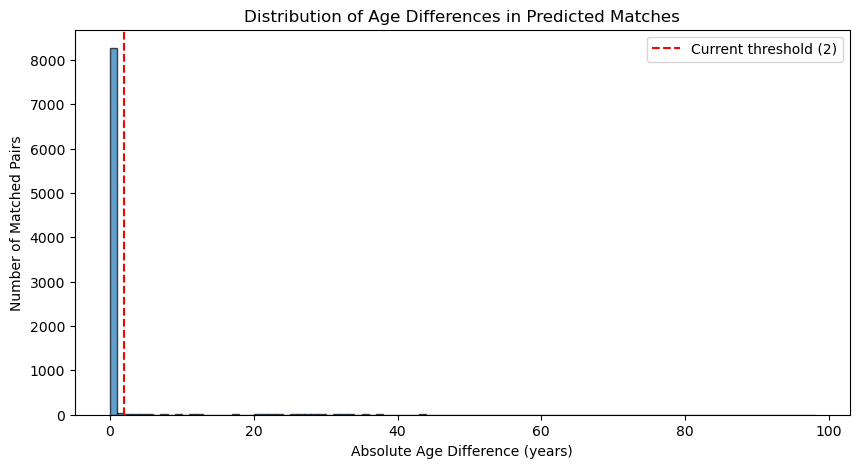

In [23]:
plt.figure(figsize=(10,5))
plt.hist(ages_differences, bins=range(0, max(ages_differences) +2), edgecolor='black', alpha=0.7)
plt.xlabel('Absolute Age Difference (years)')
plt.ylabel('Number of Matched Pairs')
plt.title('Distribution of Age Differences in Predicted Matches')
plt.axvline(x=2, color='red', linestyle='--', label='Current threshold (2)')
plt.legend()
plt.show()

In [24]:
# Adding summary stats
print(f'Median: {np.median(ages_differences):.2f}')
print(f'90th percentile: {np.percentile(ages_differences, 90):.2f}')
print(f'95th percenticle: {np.percentile(ages_differences, 95):.2f}')
print(f'96th percenticle: {np.percentile(ages_differences, 96):.2f}')
print(f'97th percenticle: {np.percentile(ages_differences, 97):.2f}')
print(f'98th percenticle: {np.percentile(ages_differences, 98):.2f}')

Median: 0.00
90th percentile: 0.00
95th percenticle: 0.00
96th percenticle: 1.00
97th percenticle: 9.00
98th percenticle: 23.00


- El salto de 1 a 9 entre el percentil 96 y el 97 reveló una clara **brecha** en la distribución. Esto confirma que los datos se separan naturalmente en coincidencias reales con una diferencia de 0 a 1 año y falsos positivos con una diferencia de más de 9 años.

- The jump from 1 to 9 between the 96th and 97th percentile revealed a clear **gap** in the distribution. This confirmed the data naturally separates into "real matches with 0-1 year difference" and "false positives with 9+ year difference

In [25]:
bool_age_arr = (abs
                (df_customer_db.loc[matching_unsupervised_output.get_level_values(0), 'age'].values 
                 - df_crm.loc[matching_unsupervised_output.get_level_values(1), 'age'].values) >= 2)

In [26]:
matching_unsupervised_output[bool_age_arr]

MultiIndex([(24796, 26110),
            (24971, 30781),
            (25231, 29740),
            (26530, 31882),
            ( 5006,  5004),
            (26195, 26196),
            (29095, 21037),
            (21892, 32453),
            (14369, 14030),
            ( 5004, 33215),
            ...
            (21756, 24719),
            ( 7934,  7935),
            ( 7934,  7936),
            ( 7242,  7239),
            (17508, 17509),
            ( 6321, 30978),
            ( 6321,  6323),
            ( 1127,  3244),
            (17390, 28453),
            ( 5982,  6496)],
           names=['customer_id_1', 'customer_id_2'], length=323)

In [27]:
# Removing pairs mathces with equals o more than 2 years of difference
mulIndex_ages_cleaned = matching_unsupervised_output[~bool_age_arr]
mulIndex_ages_cleaned

MultiIndex([( 1641,  1641),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            (28332,  4556),
            (28332, 28332),
            ...
            (30532, 26494),
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8318)

In [28]:
print(f'Removed: {bool_age_arr.sum()}')
print(f'After age filtered: {len(mulIndex_ages_cleaned)}')

Removed: 323
After age filtered: 8318


In [29]:
pd.Series(mulIndex_ages_cleaned.get_level_values(0)).value_counts().head(10)

customer_id_1
3788     2
13897    2
2330     2
27963    2
30576    2
16713    2
32663    2
14584    2
28088    2
32814    2
Name: count, dtype: int64

In [30]:
pd.Series(mulIndex_ages_cleaned.get_level_values(1)).value_counts().head(10)

customer_id_2
23917    4
25331    4
23971    3
21702    3
13349    3
31606    3
19654    3
29536    3
18284    3
25011    3
Name: count, dtype: int64

In [31]:
mulIndex_ages_cleaned[mulIndex_ages_cleaned.get_level_values(1) == 23917]

MultiIndex([(23917, 23917),
            (23918, 23917),
            (29295, 23917),
            (29374, 23917)],
           names=['customer_id_1', 'customer_id_2'])

In [32]:
show_pairs_dfs(df_customer_db, df_crm, mulIndex_ages_cleaned[mulIndex_ages_cleaned.get_level_values(1) == 23917])

first_name             Benjamin
surname                    Cook
postcode                SW212NZ
age                          19
first_name_cleaned     Benjamin
surname_cleaned            Cook
postcode_cleaned        SW212NZ
phonetic_first_name        B525
phonetic_surname           C200
initials                     BC
Name: 23917, dtype: object
first_name             Benjamin
surname                    Cook
postcode                SW212NZ
age                          19
first_name_cleaned     Benjamin
surname_cleaned            Cook
postcode_cleaned        SW212NZ
phonetic_first_name        B525
phonetic_surname           C200
initials                     BC
Name: 23917, dtype: object
------------------------
first_name             Bradley
surname                   Cook
postcode               SW212NZ
age                         19
first_name_cleaned     Bradley
surname_cleaned           Cook
postcode_cleaned       SW212NZ
phonetic_first_name       B634
phonetic_surname          C200
in

Pese a haber eliminado los pares donde existia una diferencia de edad igual o mayor a 2 años y luego de revisar con que número de frequencia se están emparejando los IDs podemos ver de la consulta superior que del custumer_db dataset los ids 23917 y 29295 se emparejan con el id 23917 de crm dataset. Sin embargo si revisamos los Ids de customer_db

In [33]:
show_pairs_dfs(df_customer_db, df_crm, pd.MultiIndex.from_tuples([(23917, 23917), (29295, 23917)]))

first_name             Benjamin
surname                    Cook
postcode                SW212NZ
age                          19
first_name_cleaned     Benjamin
surname_cleaned            Cook
postcode_cleaned        SW212NZ
phonetic_first_name        B525
phonetic_surname           C200
initials                     BC
Name: 23917, dtype: object
first_name             Benjamin
surname                    Cook
postcode                SW212NZ
age                          19
first_name_cleaned     Benjamin
surname_cleaned            Cook
postcode_cleaned        SW212NZ
phonetic_first_name        B525
phonetic_surname           C200
initials                     BC
Name: 23917, dtype: object
------------------------
first_name             Benjamin
surname                    Cook
postcode                SW212NZ
age                          19
first_name_cleaned     Benjamin
surname_cleaned            Cook
postcode_cleaned        SW212NZ
phonetic_first_name        B525
phonetic_surname         

- We can see that in the custumer_db dataset there are IDs that contain the same information, from which we can deduce that there are duplicates between the same datasets. Therefore, I will proceed to eliminate any possible duplicates in the customer_db and crm datasets.

- Podemos ver que en el conjunto de datos custumer_db hay IDs que contienen la misma información, de lo que podemos deducir que hay duplicados entre los mismos conjuntos de datos. Por lo tanto, procederé a eliminar cualquier posible duplicado en los conjuntos de datos customer_db y crm.

## Detecting duplicates in each dataset

## Finding duplicates in **df_crm** dataset

In [34]:
df_crm.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER


## Indexing/Blocking

In [35]:
indexer_crm = recordlinkage.Index()
indexer_crm.block(on='initials')
possible_pairs_crm = indexer_crm.index(df_crm)
possible_pairs_crm

MultiIndex([(31071,  8442),
            (24442, 30015),
            (32838, 16482),
            ( 5182, 30344),
            ( 9402, 20371),
            ( 6387, 28385),
            ( 7880, 21401),
            ( 4059, 25715),
            ( 9438, 31388),
            (26363, 24184),
            ...
            (12684, 23232),
            (12684, 32840),
            (12684, 26946),
            (12684, 13829),
            (12684, 20964),
            (12684, 12803),
            (12684,  2313),
            (12684, 32288),
            (12684, 14870),
            (12684,  9446)],
           names=['customer_id_1', 'customer_id_2'], length=141311)

## Comparisions

In [36]:
#levenshtein for postcode
#jarowinkler for names
crm_comp = recordlinkage.Compare()
crm_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
crm_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
crm_comp.exact('age', 'age', label='age' )
crm_comp.string('postcode', 'postcode', method='levenshtein', label='postcode')
crm_comparison_output = crm_comp.compute(possible_pairs_crm, df_crm)
crm_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
31071         8442             0.638889  1.000000    0  0.000000
24442         30015            0.611111  0.550000    0  0.000000
32838         16482            0.826667  0.527778    0  0.000000
5182          30344            1.000000  0.483333    0  0.142857
9402          20371            0.447619  0.550000    0  0.142857
...                                 ...       ...  ...       ...
12684         12803            0.540741  0.458333    0  0.000000
              2313             0.904762  0.472222    0  0.142857
              32288            1.000000  0.611111    0  0.142857
              14870            0.588624  0.500000    0  0.000000
              9446             1.000000  0.611111    0  0.142857

[141311 rows x 4 columns]

## Classification

- Dado que estoy buscando posibles duplicados en el mismo conjunto de datos, optaré por una clasificación 'manual', ya que mi 'intuición' me dice que las comparaciones entre columnas del mismo conjunto de datos deberían reflejar un alto grado de similitud entre los posibles pares verdaderos.

- Since I am looking for possible duplicates in the same dataset, I will opt for a ‘manual’ classification, as ‘intuition’ tells me that comparisons between columns in the same dataset should reflect a high degree of similarity between possible true pairs. 

In [37]:
filter_manual_approach_crm =  (
    crm_comparison_output[(crm_comparison_output['first_name'] > 0.85)
                          & (crm_comparison_output['surname'] > 0.85) 
                          & (crm_comparison_output['age'] == 1 ) 
                          & (crm_comparison_output['postcode'] > 0.85)])
filter_manual_approach_crm

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
23856,31023,1.000000,1.000000,1,1.0
33143,6951,1.000000,1.000000,1,1.0
29361,18171,1.000000,1.000000,1,1.0
31607,14714,1.000000,1.000000,1,1.0
28252,10604,1.000000,1.000000,1,1.0
...,...,...,...,...,...
31193,24631,1.000000,0.893333,1,1.0
28284,24002,1.000000,0.933333,1,1.0
31751,5197,0.922222,1.000000,1,1.0


In [38]:
show_pairs_dfs(df_crm, df_crm, filter_manual_approach_crm.index, random_samples=True, number_of_samples=5)

first_name              Eloise
surname                 Cooper
postcode               HR559UG
age                         10
first_name_cleaned      Eloise
surname_cleaned         Cooper
postcode_cleaned       HR559UG
phonetic_first_name       E420
phonetic_surname          C160
initials                    EC
Name: 6501, dtype: object
first_name              Eloise
surname                 Cooper
postcode               HR559UG
age                         10
first_name_cleaned      Eloise
surname_cleaned         Cooper
postcode_cleaned       HR559UG
phonetic_first_name       E420
phonetic_surname          C160
initials                    EC
Name: 26887, dtype: object
------------------------
first_name               Ellis
surname                 Fisher
postcode               HR174XY
age                          9
first_name_cleaned       Ellis
surname_cleaned         Fisher
postcode_cleaned       HR174XY
phonetic_first_name       E420
phonetic_surname          F260
initials               

In [39]:
pd.Series(filter_manual_approach_crm.index.get_level_values(0)).value_counts().head(5)

customer_id_1
852      1
23856    1
33143    1
29361    1
31607    1
Name: count, dtype: int64

In [40]:
pd.Series(filter_manual_approach_crm.index.get_level_values(1)).value_counts().head(5)

customer_id_2
32129    1
31023    1
6951     1
18171    1
14714    1
Name: count, dtype: int64

- Aunque los emparejamientos parecen bastantes precisos vamos a chequear por posibles falsos emparejamientos
- Although the pairings seem quite accurate, we will check for possible false pairings.

In [41]:
left_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(0)
rigth_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(1)

In [42]:
columns_to_check = ['first_name_cleaned', 'surname_cleaned', 'age', 'postcode_cleaned']
suffix = '_cleaned'
diff_crm = {} # dictionary to store the results
for column in columns_to_check:
    key = 'diff_' + column.removesuffix(suffix) + '_crm_pairs'
    diff_crm[key] = filter_manual_approach_crm[~(df_crm.loc[left_pairs_index_crm, column].values == df_crm.loc[rigth_pairs_index_crm, column].values)]

In [43]:
def show_dfs_lengths(dict_of_dfs):
    for k, v in dict_of_dfs.items():
        print(f'Number of pairs in {k}: {len(v)}')

In [44]:
show_dfs_lengths(diff_crm)

Number of pairs in diff_first_name_crm_pairs: 40
Number of pairs in diff_surname_crm_pairs: 36
Number of pairs in diff_age_crm_pairs: 0
Number of pairs in diff_postcode_crm_pairs: 0


In [45]:
mulindex_crm_pairs_name_and_surname_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                            .intersection(diff_crm['diff_surname_crm_pairs'].index))

print(f"There are {len(mulindex_crm_pairs_name_and_surname_diff)} matches where name and surname are different")

There are 12 matches where name and surname are different


In [46]:
mulindex_crm_pairs_just_name_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                     .difference(mulindex_crm_pairs_name_and_surname_diff))

print(f"There are {len(mulindex_crm_pairs_just_name_diff)} matches were name is different")

There are 28 matches were name is different


In [47]:
mulindex_crm_pairs_just_surname_diff = (diff_crm['diff_surname_crm_pairs'].index
                                        .difference(mulindex_crm_pairs_name_and_surname_diff))

print(f"There are {len(mulindex_crm_pairs_just_surname_diff)} matches were surname is different")

There are 24 matches were surname is different


In [48]:
total_of_wrong_matches_crm = (
    (mulindex_crm_pairs_just_name_diff)
    .union(mulindex_crm_pairs_just_surname_diff)
    .union(mulindex_crm_pairs_name_and_surname_diff))

print(f'From the matches of the crm there are {len(total_of_wrong_matches_crm)} posible false matches')

From the matches of the crm there are 64 posible false matches


In [49]:
show_pairs_dfs(df_crm, df_crm, total_of_wrong_matches_crm, False)

first_name              Jayden
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jayden
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 741, dtype: object
first_name              Jaydem
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jaydem
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 29911, dtype: object
------------------------
first_name              Brandon
surname                Robinson
postcode                DE250HA
age                          21
first_name_cleaned      Brandon
surname_cleaned        Robinson
postcode_cleaned        DE250HA
phonetic_first_name        B653
phonetic_surname           R152
initials       

- Revisé manualmente los 64 pares, todos ellos coincidentes con errores de introducción de datos. No hay diferencias entre edades o códigos postales, solo errores ortográficos entre el nombre y los apellidos, por lo que he decidido considerar estas coincidencias "erróneas" como correctas.
Ahora vamos a mantener las coincidencias del nivel 0 del filtro MultiIndex filter_manual_approach_crm y eliminar del df_crm los duplicados que pertenecen al nivel 1 del filtro MultiIndex filter_manual_approach_crm.

- Manually reviewed all 64 pairs — all consistent with data entry errors. No difference between ages or postal code, just spelling mistakes bewteen name and surname, so I've decided to take this 'wrong' matches as correct ones.
Now we are goint to keep the matches of the level 0 of the MultiIndex filter_manual_approach_crm and drop from the df_crm the duplicates which belong to the level 1 of the MultiIndex filter_manual_approach_crm.

In [50]:
df_crm_deduped = df_crm.drop(filter_manual_approach_crm.index.get_level_values(1))
df_crm_deduped.shape[0]

7355

## finding duplicates in df_customer_db dataset


In [51]:
df_customer_db

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK
15306,Jack,Moore,NW908RR,26,Jack,Moore,NW908RR,J200,M600,JM
24971,Alexander,Roberts,SW500HW,85,Alexander,Roberts,SW500HW,A425,R163,AR
...,...,...,...,...,...,...,...,...,...,...
14295,Erin,Morgan,NW481EN,63,Erin,Morgan,NW481EN,E650,M625,EM
28025,Aaron,Harris,SO265RP,66,Aaron,Harris,SO265RP,A650,H620,AH
4220,Grace,Mitchell,EX709AR,20,Grace,Mitchell,EX709AR,G620,M324,GM


In [52]:
indexer_customer_db = recordlinkage.Index()
indexer_customer_db.block('initials')
possible_pairs_customer_db = indexer_customer_db.index(df_customer_db)
possible_pairs_customer_db

MultiIndex([(21784, 24971),
            (25094, 30178),
            ( 4361,   509),
            ( 5887,  7404),
            (   93, 18792),
            ( 6781,  7276),
            (13668, 22755),
            (32122, 24971),
            (32122, 21784),
            (29571, 22755),
            ...
            (29494, 31084),
            (29494, 23825),
            (29494, 24242),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918),
            (29494, 17508),
            (29494,  3695),
            (29494, 14995)],
           names=['customer_id_1', 'customer_id_2'], length=1294992)

In [53]:
customer_db_comp = recordlinkage.Compare()
customer_db_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
customer_db_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
customer_db_comp.exact('age', 'age', label='age' )
customer_db_comp.string('postcode', 'postcode', method='levenshtein', label='postcode')
customerdb_comparison_output = customer_db_comp.compute(possible_pairs_customer_db, df_customer_db)
customerdb_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
21784         24971            0.518519  0.955556    0  0.142857
25094         30178            1.000000  1.000000    0  0.142857
4361          509              0.633333  0.527778    0  0.000000
5887          7404             0.800000  0.666667    0  0.285714
93            18792            1.000000  0.555556    0  0.000000
...                                 ...       ...  ...       ...
29494         6418             0.760000  0.511905    0  0.000000
              10918            0.483333  0.464286    0  0.285714
              17508            0.483333  0.492063    0  0.142857
              3695             0.483333  0.866667    0  0.285714
              14995            0.600000  0.539683    0  0.000000

[1294992 rows x 4 columns]

In [54]:
filter_manual_approach_customerdb = (
    customerdb_comparison_output[(customerdb_comparison_output['first_name'] > 0.85) 
                                 & (customerdb_comparison_output['surname'] > 0.85) 
                                 & (customerdb_comparison_output['age'] == 1) 
                                 & (customerdb_comparison_output['postcode'] > 0.85)])
filter_manual_approach_customerdb

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
15168,30178,1.0,1.000000,1,1.000000
6303,27350,1.0,1.000000,1,1.000000
28450,17466,1.0,1.000000,1,1.000000
30817,20726,1.0,1.000000,1,1.000000
29176,9720,1.0,1.000000,1,1.000000
...,...,...,...,...,...
30392,23116,1.0,0.922222,1,1.000000
4220,30722,1.0,0.925000,1,1.000000
13086,13183,1.0,1.000000,1,0.857143


In [55]:
pd.Series(filter_manual_approach_customerdb.index.get_level_values(0)).value_counts().head(5)

customer_id_1
13086    2
3569     1
31987    1
31218    1
18595    1
Name: count, dtype: int64

In [56]:
pd.Series(filter_manual_approach_customerdb.index.get_level_values(1)).value_counts().head(5)

customer_id_2
13183    2
28094    1
25579    1
146      1
32132    1
Name: count, dtype: int64

In [57]:
left_pairs_index_customer_db = filter_manual_approach_customerdb.index.get_level_values(0)
right_pairs_index_customer_db = filter_manual_approach_customerdb.index.get_level_values(1)

## Finding name, surname, age and postal code differences

In [58]:
diff_customer_db = {}
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_customer_db[key] = filter_manual_approach_customerdb[~((df_customer_db.loc[left_pairs_index_customer_db, column].values) == (df_customer_db.loc[right_pairs_index_customer_db, column].values))]

In [59]:
show_dfs_lengths(diff_customer_db)

Number of pairs in first_name_diff: 309
Number of pairs in surname_diff: 321
Number of pairs in age_diff: 0
Number of pairs in postcode_diff: 4


In [60]:
mulindex_custdb_pairs_surname_name_diff = diff_customer_db['first_name_diff'].index.intersection(diff_customer_db['surname_diff'].index)
print(f"There are {len(mulindex_custdb_pairs_surname_name_diff)} matches were surname and name are differents")

There are 80 matches were surname and name are differents


In [61]:
mulindex_custdb_pairs_just_surname_diff = diff_customer_db['surname_diff'].index.difference(diff_customer_db['first_name_diff'].index)
print(f"There are {len(mulindex_custdb_pairs_just_surname_diff)} matches were just surname is different")

There are 241 matches were just surname is different


In [62]:
mulindex_custdb_pairs_just_name_diff = diff_customer_db['first_name_diff'].index.difference(diff_customer_db['surname_diff'].index)
print(f"There are {len(mulindex_custdb_pairs_just_name_diff)} matches were just name is different")

There are 229 matches were just name is different


In [63]:
show_pairs_dfs(df_customer_db, df_customer_db, mulindex_custdb_pairs_surname_name_diff, random_samples=True, number_of_samples=10)

first_name              Hrrvey
surname                 Hrrvey
postcode               SO527SQ
age                         51
first_name_cleaned      Hrrvey
surname_cleaned         Hrrvey
postcode_cleaned       SO527SQ
phonetic_first_name       H610
phonetic_surname          H610
initials                    HH
Name: 29429, dtype: object
first_name              Harvey
surname                 Harvey
postcode               SO527SQ
age                         51
first_name_cleaned      Harvey
surname_cleaned         Harvey
postcode_cleaned       SO527SQ
phonetic_first_name       H610
phonetic_surname          H610
initials                    HH
Name: 21892, dtype: object
------------------------
first_name              Brooxe
surname                  Baxer
postcode               SW937XP
age                         48
first_name_cleaned      Brooxe
surname_cleaned          Baxer
postcode_cleaned       SW937XP
phonetic_first_name       B620
phonetic_surname          B260
initials              

- Tras comprobar algunas de las coincidencias que contienen errores en el apellido y el nombre, se observa que se trata de errores ortográficos menores. Por lo tanto, estas coincidencias 'erróneas' se considerarán duplicados verdaderos.

- After checking some of the matches that contain errors in the last name and first name, it can be seen that these are minor spelling mistakes. Therefore, these ‘erroneous’ matches will be considered true duplicates.

In [64]:
df_custdb_deduped =  df_customer_db.drop(filter_manual_approach_customerdb.index.get_level_values(1))
df_custdb_deduped.shape[0]

19337

## Let's match the two database with their records cleaned and no duplicated

## Indexig

In [65]:
indices_2 = recordlinkage.Index()
indices_2.block('initials')
poss_indx_matches = indices_2.index(df_custdb_deduped, df_crm_deduped)
poss_indx_matches

MultiIndex([( 1641, 21710),
            ( 1641, 27643),
            ( 1641,  8174),
            ( 1641,  1641),
            ( 1641, 32623),
            ( 1641, 23330),
            ( 1641, 29180),
            ( 1641, 21330),
            ( 1641,  9695),
            ( 1641,  6002),
            ...
            (29494, 15904),
            (29494, 18273),
            (29494, 21772),
            (29494,  1886),
            (29494,  4201),
            (29494,  8108),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918)],
           names=['customer_id_1', 'customer_id_2'], length=669701)

In [66]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, poss_indx_matches, True, 3)

first_name                Ella
surname                Johnson
postcode               SO310HE
age                         41
first_name_cleaned        Ella
surname_cleaned        Johnson
postcode_cleaned       SO310HE
phonetic_first_name       E400
phonetic_surname          J525
initials                    EJ
Name: 21286, dtype: object
first_name               Emily
surname                  Jones
postcode               HR802JT
age                         46
first_name_cleaned       Emily
surname_cleaned          Jones
postcode_cleaned       HR802JT
phonetic_first_name       E540
phonetic_surname          J520
initials                    EJ
Name: 7253, dtype: object
------------------------
first_name              Alice
surname                  Shaw
postcode               DE13HN
age                        19
first_name_cleaned      Alice
surname_cleaned          Shaw
postcode_cleaned       DE13HN
phonetic_first_name      A420
phonetic_surname         S000
initials                   AS
Na

## Comparing

In [67]:
#levenshtein for postcode
#jarowinkler for names

comparisons_2 = recordlinkage.Compare()
comparisons_2.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
comparisons_2.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
comparisons_2.exact('age', 'age', label='age')
comparisons_2.string('postcode', 'postcode', method='levenshtein', label='postcode')
comparisons_2.exact('phonetic_first_name', 'phonetic_first_name', label='phonetic_first_name')
comparisons_2.exact('phonetic_surname', 'phonetic_surname', label='phonetic_surname')
comparisons_2_output = comparisons_2.compute(poss_indx_matches, df_custdb_deduped, df_crm_deduped)
comparisons_2_output

first_name   surname  age  postcode  \
customer_id_1 customer_id_2                                        
1641          21710            0.666667  0.737500    0  0.142857   
              27643            0.472222  0.950000    0  0.285714   
              8174             0.472222  0.625000    0  0.000000   
              1641             1.000000  1.000000    1  1.000000   
              32623            0.633333  0.569444    0  0.142857   
...                                 ...       ...  ...       ...   
29494         8108             0.600000  0.523810    0  0.000000   
              2651             0.483333  0.511905    0  0.142857   
              7086             0.483333  0.436508    0  0.000000   
              6418             0.760000  0.511905    0  0.000000   
              10918            0.483333  0.464286    0  0.285714   

                             phonetic_first_name  phonetic_surname  
customer_id_1 customer_id_2                                         
1641          21710                            0                 0  
              27643                            0                 1  
              8174                             0                 0  
              1641                             1                 1  
              32623                            1                 0  
...                                          ...               ...  
29494         8108                             0                 0  
              2651                             0                 0  
              7086                             0                 0  
              6418                             0                 0  
              10918                            0                 0  

[669701 rows x 6 columns]

## Classification

In [68]:
# Unsupervised
# ECMClassifier

ecmc = recordlinkage.ECMClassifier(init='jaro', binarize=0.5, max_iter=100)
ecmc.fit(comparisons_2_output)
matches_unsupervised_result = ecmc.predict(comparisons_2_output)
matches_unsupervised_result

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (28332, 28332),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=6286)

In [69]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, matches_unsupervised_result, True)

first_name               Logan
surname                Collins
postcode               HR496RG
age                         22
first_name_cleaned       Logan
surname_cleaned        Collins
postcode_cleaned       HR496RG
phonetic_first_name       L250
phonetic_surname          C452
initials                    LC
Name: 6219, dtype: object
first_name               Logan
surname                Collins
postcode               HR496RG
age                         22
first_name_cleaned       Logan
surname_cleaned        Collins
postcode_cleaned       HR496RG
phonetic_first_name       L250
phonetic_surname          C452
initials                    LC
Name: 26997, dtype: object
------------------------
first_name                    Ava
surname                Richardson
postcode                  DE934NT
age                             4
first_name_cleaned            Ava
surname_cleaned        Richardson
postcode_cleaned          DE934NT
phonetic_first_name          A100
phonetic_surname             R

In [70]:
pd.Series(matches_unsupervised_result.get_level_values(0)).value_counts()

customer_id_1
25622    3
18627    2
21904    2
287      2
2904     2
        ..
22059    1
22009    1
5982     1
30392    1
875      1
Name: count, Length: 6174, dtype: int64

In [71]:
pd.Series(matches_unsupervised_result.get_level_values(1)).value_counts().head(5)

customer_id_2
24719    5
24689    5
14803    3
28203    3
30193    3
Name: count, dtype: int64

In [72]:
matches_unsupervised_result[matches_unsupervised_result.get_level_values(1) == 24719 ]

MultiIndex([(24689, 24719),
            (24719, 24719),
            (24718, 24719),
            (21554, 24719),
            (21756, 24719)],
           names=['customer_id_1', 'customer_id_2'])

In [73]:
show_pairs_dfs(df_custdb_deduped, 
               df_crm_deduped, 
               matches_unsupervised_result[matches_unsupervised_result.get_level_values(1) == 24719 ],
               False)

first_name              Isabella
surname                Robertson
postcode                 SW433XU
age                           22
first_name_cleaned      Isabella
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24689, dtype: object
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24719, dtype: object
------------------------
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I2

- Chequeamos manualmente los emparejamientos relizados al id 24719 que proviene del crm dataset, podemos ver que dicho id solo es emparejado correctamente con el id 24719 del db_customer dataset, los otros emparejamientos tienen diferencias notables en edad, ciertos errores en los nombres o apellido y codigo postal, por lo tanto voy a buscar y descartar estos falsos positivos emparejamientos. 

- We manually check the matches made to id 24719 from the CRM dataset and see that this id is only correctly matched with id 24719 from the db_customer dataset. The other matches have notable differences in age, certain errors in first or last names, and postal codes. Therefore, I will search for and discard these false positive matches. 

In [74]:
left_pairs_index_matches = matches_unsupervised_result.get_level_values(0)
right_pairs_index_matches = matches_unsupervised_result.get_level_values(1)


## Looking for ages, names, surname and postal code differnces

In [75]:
diff_between_dataset_pairs = {}
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_between_dataset_pairs[key] = (
        matches_unsupervised_result[~(df_custdb_deduped.loc[left_pairs_index_matches, column].values 
                                      == df_crm_deduped.loc[right_pairs_index_matches, column].values)]) 

In [76]:
show_dfs_lengths(diff_between_dataset_pairs)

Number of pairs in first_name_diff: 285
Number of pairs in surname_diff: 207
Number of pairs in age_diff: 299
Number of pairs in postcode_diff: 133


- Buscando coincidencias de pares en las que haya errores en el nombre, apellido, edad y código postal.
- Searching for matching pairs where there are errors in the first name, last name, age, and zip code.

In [77]:
wrong_surname_name_age_postcode = (diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff']))
len(wrong_surname_name_age_postcode)

14

In [78]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, wrong_surname_name_age_postcode)

first_name              Sophia
surname                  Jones
postcode               SO433HD
age                         40
first_name_cleaned      Sophia
surname_cleaned          Jones
postcode_cleaned       SO433HD
phonetic_first_name       S100
phonetic_surname          J520
initials                    SJ
Name: 21628, dtype: object
first_name              Sophie
surname                  James
postcode               SO473WT
age                         26
first_name_cleaned      Sophie
surname_cleaned          James
postcode_cleaned       SO473WT
phonetic_first_name       S100
phonetic_surname          J520
initials                    SJ
Name: 21707, dtype: object
------------------------
first_name               Grace
surname                   Hill
postcode               SO473WU
age                         39
first_name_cleaned       Grace
surname_cleaned           Hill
postcode_cleaned       SO473WU
phonetic_first_name       G620
phonetic_surname          H400
initials              

- Se chequeo manualmente los matches de wrong_surname_name_age_postcode MultiIndex y efectivamente son falsos positivos y no se tratan de la misma persona

- The matches for wrong_surname_name_age_postcode MultiIndex were checked manually and are indeed false positives and do not refer to the same person. 

## Looking for wrong match between `names` and only `names` 


In [ ]:
""" This function returns boolean masks
for each column introduce in the list_columns parameter
each boolean mask is stored in a dictionary with its respective key
"""
def get_boolean_masks(dataframe1, dataframe2, multiIndex, list_columns):
    try:
        df1 = dataframe1.loc[multiIndex.get_level_values(0), list_columns]
        df2 = dataframe2.loc[multiIndex.get_level_values(1), list_columns]
        dict_mask_booleans = {}
        for column in list_columns:
            dict_mask_booleans[column] = df1[column].values == df2[column].values
        return dict_mask_booleans
    except Exception as e:
        print(f"An unexpected error ocurred: {e}")

In [80]:
columns = ['surname_cleaned', 'age', 'postcode_cleaned']
names_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['first_name_diff'], columns)
mulIndex_pairs_name_diff = (
    diff_between_dataset_pairs['first_name_diff']
    [names_boolean_mask['surname_cleaned'] & names_boolean_mask['age'] & names_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_name_diff)

134

In [81]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_name_diff, random_samples=True, number_of_samples=30)

first_name               Aidam
surname                    Lee
postcode               NW436BR
age                         34
first_name_cleaned       Aidam
surname_cleaned            Lee
postcode_cleaned       NW436BR
phonetic_first_name       A350
phonetic_surname          L000
initials                    AL
Name: 31985, dtype: object
first_name               Aidan
surname                    Lee
postcode               NW436BR
age                         34
first_name_cleaned       Aidan
surname_cleaned            Lee
postcode_cleaned       NW436BR
phonetic_first_name       A350
phonetic_surname          L000
initials                    AL
Name: 13970, dtype: object
------------------------
first_name              Suphie
surname                 Murray
postcode               PO613TN
age                         16
first_name_cleaned      Suphie
surname_cleaned         Murray
postcode_cleaned       PO613TN
phonetic_first_name       S100
phonetic_surname          M600
initials              

- Las coincidencias de mulIndex_pairs_name_diff MultiIndex se comprueban aleatoriamente de forma manual y se observan diferencias sutiles entre los nombres; por lo tanto, estas coincidencias se considerarán correctas.

- The matches of mulIndex_pairs_name_diff MultiIndex are randomly checked manually, and subtle differences between the names are found, therefore, these matches will considered correct.

## Looking for wrong match between `surnames` and only `surnames` 

In [82]:
columns = ['first_name_cleaned', 'age', 'postcode_cleaned']
surnnames_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['surname_diff'], columns)
mulIndex_pairs_surname_diff = (
    diff_between_dataset_pairs['surname_diff']
    [surnnames_boolean_mask['first_name_cleaned'] & surnnames_boolean_mask['age'] & surnnames_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_surname_diff)

128

In [83]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_surname_diff, random_samples=True, number_of_samples=30)

first_name                Jacob
surname                Phiiiips
postcode                SW988AF
age                           6
first_name_cleaned        Jacob
surname_cleaned        Phiiiips
postcode_cleaned        SW988AF
phonetic_first_name        J210
phonetic_surname           P120
initials                     JP
Name: 29844, dtype: object
first_name                Jacob
surname                Phillips
postcode                SW988AF
age                           6
first_name_cleaned        Jacob
surname_cleaned        Phillips
postcode_cleaned        SW988AF
phonetic_first_name        J210
phonetic_surname           P412
initials                     JP
Name: 26447, dtype: object
------------------------
first_name                Emma
surname                  Moore
postcode               PO200HJ
age                         13
first_name_cleaned        Emma
surname_cleaned          Moore
postcode_cleaned       PO200HJ
phonetic_first_name       E500
phonetic_surname          M600
in

- Las coincidencias de mulIndex_pairs_surname_diff MultiIndex se comprueban aleatoriamente de forma manual y se observan diferencias sutiles entre los apellidos; por lo tanto, estas coincidencias se considerarán correctas.

- The matches of mulIndex_pairs_surname_diff MultiIndex are randomly checked manually, and subtle differences between the names are found; therefore, these matches will be considered correct.

## Looking for wrong match between `age` and only `age` 


In [84]:
columns = ['first_name_cleaned', 'surname_cleaned', 'postcode_cleaned']
age_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['age_diff'], columns)
mulIndex_pairs_age_diff = (
    diff_between_dataset_pairs['age_diff']
    [age_boolean_mask['first_name_cleaned'] & age_boolean_mask['surname_cleaned'] & age_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_age_diff)

107

In [85]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_age_diff, random_samples=True, number_of_samples=30)

first_name               Ellie
surname                 Taylor
postcode               SO473WT
age                         33
first_name_cleaned       Ellie
surname_cleaned         Taylor
postcode_cleaned       SO473WT
phonetic_first_name       E400
phonetic_surname          T460
initials                    ET
Name: 21693, dtype: object
first_name               Ellie
surname                 Taylor
postcode               SO473WT
age                         13
first_name_cleaned       Ellie
surname_cleaned         Taylor
postcode_cleaned       SO473WT
phonetic_first_name       E400
phonetic_surname          T460
initials                    ET
Name: 21694, dtype: object
------------------------
first_name               Sophie
surname                Campbell
postcode                SW433XU
age                          81
first_name_cleaned       Sophie
surname_cleaned        Campbell
postcode_cleaned        SW433XU
phonetic_first_name        S100
phonetic_surname           C514
initials     

- De forma aleatoria se chequeo manualmente los matches de mulIndex_pairs_age_diffMultiIndex y se observa que si existen grandes difrencias entre las edades de muchos matches.

- The matches in mulIndex_pairs_age_diffMultiIndex are randomly checked manually, and it is observed that there are large differences between the ages of many matches.

In [86]:
right_pairs_index_matches

Index([ 1641, 26110, 24796, 14358, 15306, 30781, 24971,  7319,  7276, 28332,
       ...
       17003, 17815, 30292, 30340,  7851, 28201, 22010,  6496, 23116, 30722],
      dtype='int64', name='customer_id_2', length=6286)

In [87]:
abs_age_differece = abs(
    df_custdb_deduped.loc[mulIndex_pairs_age_diff.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[mulIndex_pairs_age_diff.get_level_values(1), 'age'].values)
abs_age_differece

array([ 2,  2,  1, 23,  1, 37, 27, 28,  2,  1,  1,  2,  1,  1,  1, 23, 29,
       37,  1,  1, 40,  1,  7, 40,  1,  5,  1, 23,  1,  9, 31, 18, 12,  1,
        1, 46,  1, 21,  2,  1,  1,  1,  1,  1, 23, 28, 26,  1, 16, 23,  1,
       29, 30, 29,  1,  1,  1, 33, 11, 18,  4,  1, 33, 21,  1,  1,  2, 15,
        1,  1,  1,  1,  1, 38, 30,  6,  1,  7, 23,  9, 23, 20,  7,  1, 11,
        1, 20,  2, 26, 22, 34, 36, 25,  1, 37, 32,  1, 25, 15,  1, 35,  1,
        4, 54, 28,  5, 15])

C:\Users\Shelton\AppData\Local\Temp\ipykernel_31828\4288267429.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


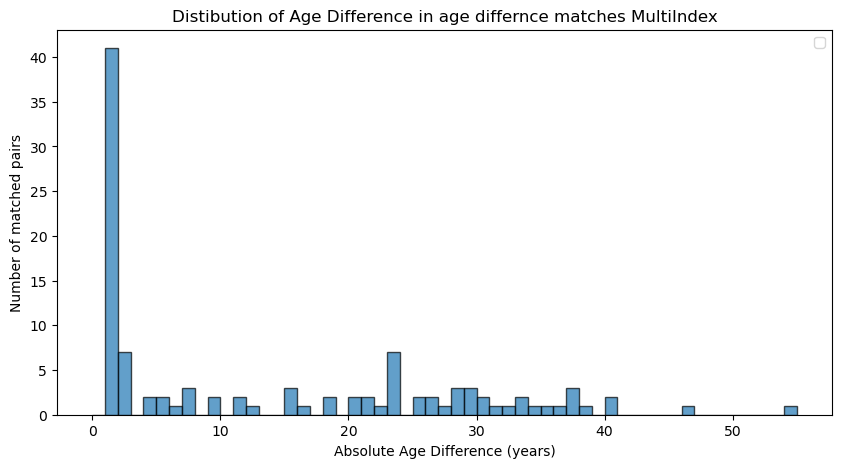

In [88]:
plt.figure(figsize=(10,5))
plt.hist(abs_age_differece, bins=range(0, max(abs_age_differece) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Absolute Age Difference (years)')
plt.ylabel('Number of matched pairs')
plt.title('Distibution of Age Difference in age differnce matches MultiIndex')
plt.legend()
plt.show()

In [89]:
print(f'Median: {np.median(abs_age_differece):.2f}')
print(f'90th percentile {np.percentile(abs_age_differece, 90):.2f}')
print(f'50th percentile {np.percentile(abs_age_differece, 50):.2f}')
print(f'40th percentile {np.percentile(abs_age_differece, 40):.2f}')
print(f'30th percentile {np.percentile(abs_age_differece, 30):.2f}')
print(f'25th percentile {np.percentile(abs_age_differece, 25):.2f}')


Median: 7.00
90th percentile 33.40
50th percentile 7.00
40th percentile 2.00
30th percentile 1.00
25th percentile 1.00


- Al observar la distribución de la diferencia de edad, se aplicará un límite de dos años, lo que significa que las coincidencias en las que haya una diferencia superior a dos años se considerarán falsos positivos y, por lo tanto, personas diferentes.

- Observing the distribution of the age difference, a limit of two years will be applied, meaning that matches where there is a difference greater than two years will be considered false positives and therefore different people.


In [90]:
positive_matches_age = mulIndex_pairs_age_diff[abs_age_differece <= 2]
len(positive_matches_age)

48

In [91]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, positive_matches_age)

first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            24
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 5006, dtype: object
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 5004, dtype: object
------------------------
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phone

## Looking for wrong match between `postal code` and only `postal code` 


In [92]:
columns = ['first_name_cleaned', 'surname_cleaned', 'age']
postal_code_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['postcode_diff'], columns)
mulIndex_pairs_postcode_diff = (
    diff_between_dataset_pairs['postcode_diff']
    [postal_code_boolean_mask['first_name_cleaned'] & postal_code_boolean_mask['surname_cleaned'] & postal_code_boolean_mask['age']])
len(mulIndex_pairs_postcode_diff)

2

In [93]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_postcode_diff, False)

first_name               Harry
surname                  Price
postcode               SW844YU
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YU
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25872, dtype: object
first_name               Harry
surname                  Price
postcode               SW844YZ
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YZ
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25997, dtype: object
------------------------
first_name             Thomas
surname                  Hall
postcode               SO53WQ
age                        23
first_name_cleaned     Thomas
surname_cleaned          Hall
postcode_cleaned       SO53WQ
phonetic_first_name      T520
phonetic_surname         H400
initials                   TH
N

- Mantenemos los emparejamientos donde existe una diferencia solo en el codigo postal como verdaderas parejas.

- Let's maintain pairings where there is only a difference in the postal code as true pairs.

### Buscando parejas en las que el apellido, el nombre y la edad sean diferentes.

### Looking for pairs match where surname, name and age are different 

In [94]:
just_surname_name_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_surname_name_age)

8

In [95]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_surname_name_age)

first_name                  Adam
surname                Robertson
postcode                 DE250HA
age                           41
first_name_cleaned          Adam
surname_cleaned        Robertson
postcode_cleaned         DE250HA
phonetic_first_name         A350
phonetic_surname            R163
initials                      AR
Name: 843, dtype: object
first_name               Aidan
surname                Roberts
postcode               DE250HA
age                         10
first_name_cleaned       Aidan
surname_cleaned        Roberts
postcode_cleaned       DE250HA
phonetic_first_name       A350
phonetic_surname          R163
initials                    AR
Name: 28203, dtype: object
------------------------
first_name             Mohammed
surname                   Clark
postcode                NW662NF
age                          46
first_name_cleaned     Mohammed
surname_cleaned           Clark
postcode_cleaned        NW662NF
phonetic_first_name        M530
phonetic_surname           

- Después de comprobar los 8 pares, se ha comprobado que realmente son emparejamientos erróneos.

- After checking the 8 pairs, it has been confirmed that they are indeed incorrect pairings.

### Buscando parejas en las que el nombre,la edad y el código postal sean diferentes.

### Looking for pairs match where name, age and postal code are different 

In [96]:
just_name_age_postcode = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_name_age_postcode)

33

In [97]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_name_age_postcode)

first_name              Alicia
surname                 Davies
postcode               DE264EW
age                         87
first_name_cleaned      Alicia
surname_cleaned         Davies
postcode_cleaned       DE264EW
phonetic_first_name       A420
phonetic_surname          D120
initials                    AD
Name: 1127, dtype: object
first_name              Alisha
surname                 Davies
postcode               EX264WW
age                          3
first_name_cleaned      Alisha
surname_cleaned         Davies
postcode_cleaned       EX264WW
phonetic_first_name       A420
phonetic_surname          D120
initials                    AD
Name: 3244, dtype: object
------------------------
first_name                  Jack
surname                Griffiths
postcode                 HR335UZ
age                           35
first_name_cleaned          Jack
surname_cleaned        Griffiths
postcode_cleaned         HR335UZ
phonetic_first_name         J200
phonetic_surname            G613
initia

- Después de comprobar los 33 pares, se ha comprobado que realmente son emparejamientos erróneos.

- After checking the 33 pairs, it has been confirmed that they are indeed incorrect pairings.

### Buscando parejas en las que el apellido,la edad y el código postal sean diferentes.

### Looking for pairs match where surname, age and postal code are different 

In [98]:
just_age_postcode_surname = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_age_postcode_surname)

16

In [99]:
show_pairs_dfs(df_customer_db, df_crm_deduped, just_age_postcode_surname)

first_name               Harry
surname                  Jones
postcode               EX982LY
age                          2
first_name_cleaned       Harry
surname_cleaned          Jones
postcode_cleaned       EX982LY
phonetic_first_name       H600
phonetic_surname          J520
initials                    HJ
Name: 5054, dtype: object
first_name               Harry
surname                  James
postcode               EX975XY
age                         28
first_name_cleaned       Harry
surname_cleaned          James
postcode_cleaned       EX975XY
phonetic_first_name       H600
phonetic_surname          J520
initials                    HJ
Name: 4931, dtype: object
------------------------
first_name                Ruby
surname                 Murray
postcode               LS233HZ
age                         42
first_name_cleaned        Ruby
surname_cleaned         Murray
postcode_cleaned       LS233HZ
phonetic_first_name       R100
phonetic_surname          M600
initials                

- Después de comprobar los 16 pares, se ha comprobado que realmente son emparejamientos erróneos.

- After checking the 16 pairs, it has been confirmed that they are indeed incorrect pairings.

### Buscando parejas en las que el nombre, el apellido y el código postal sean diferentes.

### Looking for pairs match where name, surname and postal code are different 

In [100]:
just_postcode_surname_name = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_postcode_surname_name)

4

In [101]:
show_pairs_dfs(df_customer_db, df_crm_deduped, just_postcode_surname_name)

first_name                Lola
surname                  Adams
postcode               DE352AN
age                         70
first_name_cleaned        Lola
surname_cleaned          Adams
postcode_cleaned       DE352AN
phonetic_first_name       L400
phonetic_surname          A352
initials                    LA
Name: 1177, dtype: object
first_name                 Lily
surname                Anderson
postcode                DE732EN
age                          70
first_name_cleaned         Lily
surname_cleaned        Anderson
postcode_cleaned        DE732EN
phonetic_first_name        L400
phonetic_surname           A536
initials                     LA
Name: 2527, dtype: object
------------------------
first_name              Millie
surname                 Clarke
postcode               LS849ZL
age                         30
first_name_cleaned      Millie
surname_cleaned         Clarke
postcode_cleaned       LS849ZL
phonetic_first_name       M400
phonetic_surname          C462
initials      

- Después de comprobar los 4 pares, se ha comprobado que realmente son emparejamientos erróneos.

- After checking the 4 pairs, it has been confirmed that they are indeed incorrect pairings.

### Buscando parejas en las que solo nombre y el apellido sean diferentes.

### Looking for pairs match where only name and surname are different.

In [102]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)

just_surname_name = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_name))

29


In [103]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_surname_name)

first_name              Amelia
surname                Simpson
postcode               DE256NJ
age                         77
first_name_cleaned      Amelia
surname_cleaned        Simpson
postcode_cleaned       DE256NJ
phonetic_first_name       A540
phonetic_surname          S512
initials                    AS
Name: 1065, dtype: object
first_name              Ameiia
surname                Simfson
postcode               DE256NJ
age                         77
first_name_cleaned      Ameiia
surname_cleaned        Simfson
postcode_cleaned       DE256NJ
phonetic_first_name       A500
phonetic_surname          S512
initials                    AS
Name: 33064, dtype: object
------------------------
first_name                Lucy
surname                   Hunt
postcode               HR478ER
age                         54
first_name_cleaned        Lucy
surname_cleaned           Hunt
postcode_cleaned       HR478ER
phonetic_first_name       L200
phonetic_surname          H530
initials               

- Tras comprobar los 29 pares, se ha observado que las diferencias en los nombres y apellidos se deben a errores tipográficos que dan lugar a faltas ortográficas. Lo más probable es que estos 29 pares sean coincidencias reales, que conservaremos.

- After checking the 29 pairs, it has been observed that the differences in first and last names are due to typing errors resulting in misspellings. Most likely, these 29 pairs are true matches, which we will keep. 

### Buscando parejas en las que solo nombre y edad sean diferentes.

### Looking for pairs match where only name and age are different.

In [104]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_name_age = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(sum_intersecctions)
)
print(len(just_name_age))

57


In [105]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_name_age)

first_name               Georgia
surname                Griffiths
postcode                 DE500JF
age                           32
first_name_cleaned       Georgia
surname_cleaned        Griffiths
postcode_cleaned         DE500JF
phonetic_first_name         G620
phonetic_surname            G613
initials                      GG
Name: 1665, dtype: object
first_name                George
surname                Griffiths
postcode                 DE500JF
age                            5
first_name_cleaned        George
surname_cleaned        Griffiths
postcode_cleaned         DE500JF
phonetic_first_name         G620
phonetic_surname            G613
initials                      GG
Name: 1666, dtype: object
------------------------
first_name               Louis
surname                  Allen
postcode               EX423JW
age                         36
first_name_cleaned       Louis
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surnam

In [106]:
mask_one_year_diff = abs(
    df_custdb_deduped.loc[just_name_age.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[just_name_age.get_level_values(1), 'age'].values) == 1

just_name_age_one_year_diff = just_name_age[mask_one_year_diff]

show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_name_age_one_year_diff)

first_name               Louis
surname                  Allen
postcode               EX423JW
age                         36
first_name_cleaned       Louis
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surname          A450
initials                    LA
Name: 3715, dtype: object
first_name                Lois
surname                  Allen
postcode               EX423JW
age                         37
first_name_cleaned        Lois
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surname          A450
initials                    LA
Name: 3716, dtype: object
------------------------
first_name             Florenoe
surname                  Rogers
postcode                SW162HY
age                          23
first_name_cleaned     Florenoe
surname_cleaned          Rogers
postcode_cleaned        SW162HY
phonetic_first_name        F465
phonetic_surname           R262
initials       

- Después de revisar las 57 coincidencias, casi todas tienen una diferencia notable entre las edades y una diferencia más o menos grande en los nombres, así que decidí mantener solo las coincidencias verdaderas donde la diferencia de edad es menor o igual a 1 y la diferencia de nombres se debe solo a errores ortográficos.

- After checking the 57 matches almost all of them have a notable difference between ages and less or more difference in the names, so I decided only to keep as true matches where the difference of age is less or equal than 1 and the difference of names is just by spelling mistakes.

### Buscando parejas en las que solo nombre y el código postal sean diferentes.

### Looking for pairs match where only name and postal code are different.

In [107]:
# just name and postcode errors = name ∩ postcode ∩ surname exclusive ∩ age exclusive
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

In [108]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_name_postcode)

first_name               Tyler
surname                   Owen
postcode               PO416LE
age                         12
first_name_cleaned       Tyler
surname_cleaned           Owen
postcode_cleaned       PO416LE
phonetic_first_name       T460
phonetic_surname          O500
initials                    TO
Name: 16629, dtype: object
first_name               Tilly
surname                   Owen
postcode               PO466DU
age                         12
first_name_cleaned       Tilly
surname_cleaned           Owen
postcode_cleaned       PO466DU
phonetic_first_name       T400
phonetic_surname          O500
initials                    TO
Name: 16766, dtype: object
------------------------
first_name                 Zak
surname                 Gibson
postcode               SW122AH
age                         22
first_name_cleaned         Zak
surname_cleaned         Gibson
postcode_cleaned       SW122AH
phonetic_first_name       Z200
phonetic_surname          G125
initials              

- Después de comprobar los 6 pares de coincidencias, es probable que se trate de personas diferentes.

- After checking the 6 pairs of matches they are are likely different people.

In [109]:
# Number of pairs in first_name_diff: 285

subset_name = (
    mulIndex_pairs_name_diff
    .union(just_surname_name)
    .union(just_name_age)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_name_postcode)
    .union(wrong_surname_name_age_postcode))

len(subset_name)

285

### Buscando parejas en las que solo apellido y el código postal sean diferentes.

### Looking for pairs match where only surname and postal code are different.

In [110]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)
just_surname_postcode = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_postcode))

1


In [111]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_surname_postcode)

first_name               Ruby
surname                Gibson
postcode               SO53WQ
age                        55
first_name_cleaned       Ruby
surname_cleaned        Gibson
postcode_cleaned       SO53WQ
phonetic_first_name      R100
phonetic_surname         G125
initials                   RG
Name: 27535, dtype: object
first_name                  Ruby
surname                Griffiths
postcode                 SO473WT
age                           55
first_name_cleaned          Ruby
surname_cleaned        Griffiths
postcode_cleaned         SO473WT
phonetic_first_name         R100
phonetic_surname            G613
initials                      RG
Name: 21702, dtype: object
------------------------


- Después de comprobar manualmente la única coincidencia, es probable que se trate de personas diferentes.

- After checking manually the only pair match, it's likely they are different people

### Buscando parejas en las que solo nombre y código sean diferentes.

### Looking for pairs match where only name and postal code are different.

In [112]:
# just name and postcode errors = name ∩ postcode ∩ surname exclusive ∩ age exclusive
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

- Después de comprobar manualmente los 6 pares, es probable que se trate de personas diferentes.

- After checking manually the 6 pairs, it's likely they are different people. 

In [113]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_name_postcode)

first_name               Tyler
surname                   Owen
postcode               PO416LE
age                         12
first_name_cleaned       Tyler
surname_cleaned           Owen
postcode_cleaned       PO416LE
phonetic_first_name       T460
phonetic_surname          O500
initials                    TO
Name: 16629, dtype: object
first_name               Tilly
surname                   Owen
postcode               PO466DU
age                         12
first_name_cleaned       Tilly
surname_cleaned           Owen
postcode_cleaned       PO466DU
phonetic_first_name       T400
phonetic_surname          O500
initials                    TO
Name: 16766, dtype: object
------------------------
first_name                 Zak
surname                 Gibson
postcode               SW122AH
age                         22
first_name_cleaned         Zak
surname_cleaned         Gibson
postcode_cleaned       SW122AH
phonetic_first_name       Z200
phonetic_surname          G125
initials              

### Buscando parejas en las que solo apellido y la edad sean diferentes.

### Looking for pairs match where only surname and agee are different.

In [114]:
# just surname and age errors = surname ∩ age ∩ name exclusive ∩ postcode exclusive
just_surname_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['first_name_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['postcode_diff']))
    ))
)
len(just_surname_age)


7

In [115]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_surname_age)

first_name               Lacey
surname                Roberts
postcode               PO827ER
age                         98
first_name_cleaned       Lacey
surname_cleaned        Roberts
postcode_cleaned       PO827ER
phonetic_first_name       L200
phonetic_surname          R163
initials                    LR
Name: 18155, dtype: object
first_name                 Lacey
surname                Robertson
postcode                 PO827ER
age                           22
first_name_cleaned         Lacey
surname_cleaned        Robertson
postcode_cleaned         PO827ER
phonetic_first_name         L200
phonetic_surname            R163
initials                      LR
Name: 18186, dtype: object
------------------------
first_name                 Emily
surname                Robertson
postcode                 PO613TJ
age                           62
first_name_cleaned         Emily
surname_cleaned        Robertson
postcode_cleaned         PO613TJ
phonetic_first_name         E540
phonetic_surname 

- Después de comprobar manualmente los 7 pares, es probable que se trate de personas diferentes.
- After checking manually the 7 pairs, it's likely they are different people. 

In [116]:
# Number of pairs in surname_diff: 207

subset_surname = (
    mulIndex_pairs_surname_diff
    .union(just_surname_name)
    .union(just_surname_postcode)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_age_postcode_surname)
    .union(just_surname_age)
    .union(wrong_surname_name_age_postcode))
len(subset_surname)

207

### Buscando parejas en las que solo edad y el código postal sean diferentes.

### Looking for pairs match where only name and postal code are different.

In [117]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_postcode_age = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_postcode_age))

57


In [118]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_postcode_age)

first_name             Cameron
surname                Simpson
postcode                DE13HL
age                         82
first_name_cleaned     Cameron
surname_cleaned        Simpson
postcode_cleaned        DE13HL
phonetic_first_name       C565
phonetic_surname          S512
initials                    CS
Name: 221, dtype: object
first_name             Cameron
surname                Simpson
postcode               DE159LU
age                         17
first_name_cleaned     Cameron
surname_cleaned        Simpson
postcode_cleaned       DE159LU
phonetic_first_name       C565
phonetic_surname          S512
initials                    CS
Name: 407, dtype: object
------------------------
first_name              Samuel
surname                   Webb
postcode               DE237GG
age                         27
first_name_cleaned      Samuel
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       S540
phonetic_surname          W100
initials                  

In [126]:
mask_postcode_age_less_1_years = abs(
    df_custdb_deduped.loc[just_postcode_age.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[just_postcode_age.get_level_values(1), 'age'].values) == 1

just_postcode_age_less_1_years = just_postcode_age[mask_postcode_age_less_1_years]

show_pairs_dfs(df_custdb_deduped, df_crm_deduped, just_postcode_age_less_1_years)

first_name              Madison
surname                Harrison
postcode                EX400WU
age                           9
first_name_cleaned      Madison
surname_cleaned        Harrison
postcode_cleaned        EX400WU
phonetic_first_name        M325
phonetic_surname           H625
initials                     MH
Name: 3648, dtype: object
first_name              Madison
surname                Harrison
postcode                EX423JU
age                           8
first_name_cleaned      Madison
surname_cleaned        Harrison
postcode_cleaned        EX423JU
phonetic_first_name        M325
phonetic_surname           H625
initials                     MH
Name: 3667, dtype: object
------------------------
first_name                Ella
surname                  Green
postcode               HR802JT
age                         95
first_name_cleaned        Ella
surname_cleaned          Green
postcode_cleaned       HR802JT
phonetic_first_name       E400
phonetic_surname          G650
init

- Después de comprobar manualmente los pares en los que la diferencia es igual a 1 año, existe la posibilidad de que se trate de las mismas personas. El resto de coincidencias se consideran falsos positivos, ya que no se trata de las mismas personas

- After manually checking the pairs where the difference is equal to one year, there is a possibility that they are the same people. The rest of the matches are considered false positives, as they are not the same people.


In [127]:
# Number of pairs in postcode_diff: 133
subset_postcode = (
    mulIndex_pairs_postcode_diff
    .union(just_surname_postcode)
    .union(just_name_postcode)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_postcode_age)
    .union(wrong_surname_name_age_postcode))
len(subset_postcode)

133

In [128]:
# Number of pairs in age_diff: 299
subset_age = (
    mulIndex_pairs_age_diff
    .union(just_postcode_age)
    .union(just_surname_age)
    .union(just_name_age)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_surname_name_age)
    .union(wrong_surname_name_age_postcode))
len(subset_age)

299

In [132]:
mulIndex_possible_false_matches = (
    wrong_surname_name_age_postcode # 1
    .union(mulIndex_pairs_age_diff) # 2
    .union(mulIndex_pairs_name_diff) # 3 
    .union(mulIndex_pairs_surname_diff) # 4
    .union(mulIndex_pairs_postcode_diff) # 5
    .union(just_name_age) # 6
    .union(just_surname_name) # 7
    .union(just_surname_postcode) # 8
    .union(just_postcode_age) # 9
    .union(just_name_postcode) # 10
    .union(just_surname_age) # 11
    .union(just_postcode_surname_name) # 12
    .union(just_surname_name_age) # 13
    .union(just_name_age_postcode) # 14
    .union(just_age_postcode_surname) # 15
)
len(mulIndex_possible_false_matches)

603

In [133]:
# MultiIndex of correct matches
bool_mask_for_correct_matches = get_boolean_masks(
    df_custdb_deduped, df_crm_deduped, matches_unsupervised_result, 
    ['first_name_cleaned','surname_cleaned', 'age', 'postcode_cleaned'])

mulIndex_true_matches = matches_unsupervised_result[bool_mask_for_correct_matches['first_name_cleaned']
                            & bool_mask_for_correct_matches['surname_cleaned']
                            & bool_mask_for_correct_matches['age']
                            & bool_mask_for_correct_matches['postcode_cleaned']]

In [134]:
(len(mulIndex_possible_false_matches) + len(mulIndex_true_matches)) - len(matches_unsupervised_result)

0

Getting the final datase between db_customer and crm datasets

In [139]:
mulIndex_true_matches.get_level_values(1)

Index([ 1641, 24796, 14358, 15306, 24971,  7276, 28332, 18792,  1487,  7404,
       ...
       17104, 21353, 25983, 28471,  2797,  2222,  8046, 18624, 17815,  7851],
      dtype='int64', name='customer_id_2', length=5683)

In [182]:
left_side_dupled_datasets = (
    mulIndex_true_matches.get_level_values(0)
    .union(mulIndex_pairs_name_diff.get_level_values(0))
    .union(mulIndex_pairs_surname_diff.get_level_values(0))
    .union(positive_matches_age.get_level_values(0))
    .union(mulIndex_pairs_postcode_diff.get_level_values(0))
    .union(just_surname_name.get_level_values(0))
    .union(just_name_age_one_year_diff.get_level_values(0))       
    .union(just_postcode_age_less_1_years.get_level_values(0))
    )


In [184]:
rigth_side_dupled_datasets = (
    mulIndex_true_matches.get_level_values(1)
    .union(mulIndex_pairs_name_diff.get_level_values(1))
    .union(mulIndex_pairs_surname_diff.get_level_values(1))
    .union(positive_matches_age.get_level_values(1))
    .union(mulIndex_pairs_postcode_diff.get_level_values(1))
    .union(just_surname_name.get_level_values(1))
    .union(just_name_age_one_year_diff.get_level_values(1))
    .union(just_postcode_age_less_1_years.get_level_values(1))
    )

In [ ]:
df_cust_crm_deduped = pd.concat([df_custdb_deduped, df_crm_deduped.drop(rigth_side_dupled_datasets)])
df_cust_crm_deduped

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK
15306,Jack,Moore,NW908RR,26,Jack,Moore,NW908RR,J200,M600,JM
24971,Alexander,Roberts,SW500HW,85,Alexander,Roberts,SW500HW,A425,R163,AR
...,...,...,...,...,...,...,...,...,...,...
28678,Rayyaw,Jowes,DE422HD,65,Rayyaw,Jowes,DE422HD,R000,J200,RJ
15184,Martha,Martin,NW817TL,28,Martha,Martin,NW817TL,M630,M635,MM
1804,Summer,Green,DE500JH,17,Summer,Green,DE500JH,S560,G650,SG


In [ ]:
df_cust_crm_deduped[(df_cust_crm_deduped['first_name_cleaned'] == 'Mohammed') & (df_cust_crm_deduped['surname_cleaned'] == 'Richards')]

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
6280,Mohammed,Richards,HR496RJ,72,Mohammed,Richards,HR496RJ,M530,R263,MR
216,Mohammed,Richards,DE13HL,8,Mohammed,Richards,DE13HL,M530,R263,MR
25117,Mohammed,Richards,SW500HZ,0,Mohammed,Richards,SW500HZ,M530,R263,MR


In [ ]:
df_cust_crm_deduped[(df_cust_crm_deduped['first_name_cleaned'] == 'Corey') & (df_cust_crm_deduped['surname_cleaned'] == 'Mitchell')]

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
27290,Corey,Mitchell,HR348JQ,46,Corey,Mitchell,HR348JQ,C600,M324,CM
